# Q3: Feature Engineering and Regression Pipeline

This notebook builds a reproducible scikit-learn regression pipeline to predict `items_sold` at a retail store.

The main steps are:

1. Date feature engineering  
2. Temporal train-test split  
3. Preprocessing pipeline  
4. Linear Regression and Random Forest Regression  
5. Model evaluation using RMSE and MAE  
6. Feature importance interpretation

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error

In [3]:
df = pd.read_csv("C:/Users/msoni/Downloads/q3_retail_promotions.csv")

df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249
3,2022-01-02,17,small,urban,free_gift,1,0,7,259
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277


In [4]:
print("Dataset shape:")
print(df.shape)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nFirst five rows:")
display(df.head())

Dataset shape:
(1200, 9)

Data types:
transaction_date         str
store_id               int64
store_size               str
location_type            str
promotion_type           str
is_weekend             int64
is_festival            int64
competition_density    int64
items_sold             int64
dtype: object

Missing values:
transaction_date       0
store_id               0
store_size             0
location_type          0
promotion_type         0
is_weekend             0
is_festival            0
competition_density    0
items_sold             0
dtype: int64

First five rows:


,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249
3,2022-01-02,17,small,urban,free_gift,1,0,7,259
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277


In [5]:
df["transaction_date"] = pd.to_datetime(df["transaction_date"])

df["year"] = df["transaction_date"].dt.year
df["month"] = df["transaction_date"].dt.month
df["day_of_week"] = df["transaction_date"].dt.dayofweek

df["is_month_end"] = np.where(df["transaction_date"].dt.day > 25, 1, 0)

df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,is_month_end
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5,0
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5,0
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6,0
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,6,0
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0,0


In [6]:
df[["transaction_date", "year", "month", "day_of_week", "is_month_end"]].head()

,transaction_date,year,month,day_of_week,is_month_end
0,2022-01-01,2022,1,5,0
1,2022-01-01,2022,1,5,0
2,2022-01-02,2022,1,6,0
3,2022-01-02,2022,1,6,0
4,2022-01-03,2022,1,0,0


## Date Feature Engineering

The `transaction_date` column was converted into datetime format. From this date column, four new features were created:

- `year`
- `month`
- `day_of_week`
- `is_month_end`

The `is_month_end` feature is a binary variable where transactions after the 25th day of the month are marked as 1, otherwise 0. These date-based features can help the model capture seasonal, weekly, and month-end sales patterns.

In [7]:
df = df.sort_values("transaction_date").reset_index(drop=True)

df[["transaction_date", "items_sold"]].head()

,transaction_date,items_sold
0,2022-01-01,224
1,2022-01-01,348
2,2022-01-02,249
3,2022-01-02,259
4,2022-01-03,277


In [8]:
target = "items_sold"

# Drop target and original date column from model features
X = df.drop(columns=[target, "transaction_date"])
y = df[target]

split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("\nTraining date range:")
print(df["transaction_date"].iloc[:split_index].min(), "to", df["transaction_date"].iloc[:split_index].max())

print("\nTesting date range:")
print(df["transaction_date"].iloc[split_index:].min(), "to", df["transaction_date"].iloc[split_index:].max())

Training data shape: (960, 11)
Testing data shape: (240, 11)

Training date range:
2022-01-01 00:00:00 to 2024-06-11 00:00:00

Testing date range:
2024-06-12 00:00:00 to 2024-12-31 00:00:00


## Temporal Train-Test Split

The dataset was sorted by `transaction_date`. The oldest 80% of records were used for training, and the most recent 20% were used for testing.

A random split is inappropriate for time-ordered data because it can cause data leakage. In real business situations, models are trained on past data and used to predict future outcomes. If random splitting is used, future patterns may enter the training set, making the model evaluation unrealistically optimistic.

In [9]:
categorical_features = ["promotion_type", "location_type", "store_size"]

numerical_features = [
    col for col in X_train.columns
    if col not in categorical_features
]

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['promotion_type', 'location_type', 'store_size']

Numerical features:
['store_id', 'is_weekend', 'is_festival', 'competition_density', 'year', 'month', 'day_of_week', 'is_month_end']


In [11]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numerical_features)
    ]
)

## Preprocessing Pipeline

A scikit-learn `ColumnTransformer` was used for preprocessing.

- `promotion_type`, `location_type`, and `store_size` were one-hot encoded because they are categorical variables.
- Numerical features were scaled using `StandardScaler`.

The preprocessing step is included inside the model pipeline. This ensures that preprocessing is fitted only on the training data and then applied to the test data, which prevents data leakage.

In [12]:
linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

random_forest_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

In [13]:
linear_model.fit(X_train, y_train)
random_forest_model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")
print("Random Forest Regressor model trained successfully.")

Linear Regression model trained successfully.
Random Forest Regressor model trained successfully.


In [14]:
def evaluate_regression_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    
    print("=" * 50)
    print(model_name)
    print("=" * 50)
    print("RMSE:", rmse)
    print("MAE:", mae)
    
    return {
        "Model": model_name,
        "RMSE": rmse,
        "MAE": mae,
        "Predictions": y_pred
    }

In [15]:
linear_results = evaluate_regression_model(
    linear_model,
    X_test,
    y_test,
    "Linear Regression"
)

rf_results = evaluate_regression_model(
    random_forest_model,
    X_test,
    y_test,
    "Random Forest Regressor"
)

Linear Regression
RMSE: 27.114314576361732
MAE: 21.048595843888187
Random Forest Regressor
RMSE: 30.582085564918554
MAE: 24.05325


In [16]:
results_df = pd.DataFrame([
    {
        "Model": linear_results["Model"],
        "RMSE": linear_results["RMSE"],
        "MAE": linear_results["MAE"]
    },
    {
        "Model": rf_results["Model"],
        "RMSE": rf_results["RMSE"],
        "MAE": rf_results["MAE"]
    }
])

results_df

,Model,RMSE,MAE
0,Linear Regression,27.114315,21.048596
1,Random Forest Regressor,30.582086,24.053250


## Model Evaluation

The Linear Regression and Random Forest Regressor models were evaluated using RMSE and MAE.

Linear Regression achieved an RMSE of **27.114315** and an MAE of **21.048596**. Random Forest Regressor achieved an RMSE of **30.582086** and an MAE of **24.053250**.

Since lower RMSE and MAE values indicate better performance, the **Linear Regression model performed better** on the test set. This means Linear Regression made smaller prediction errors when predicting `items_sold` compared to the Random Forest Regressor.

In this case, the simpler Linear Regression model is preferable because it provides better accuracy on the most recent test data.

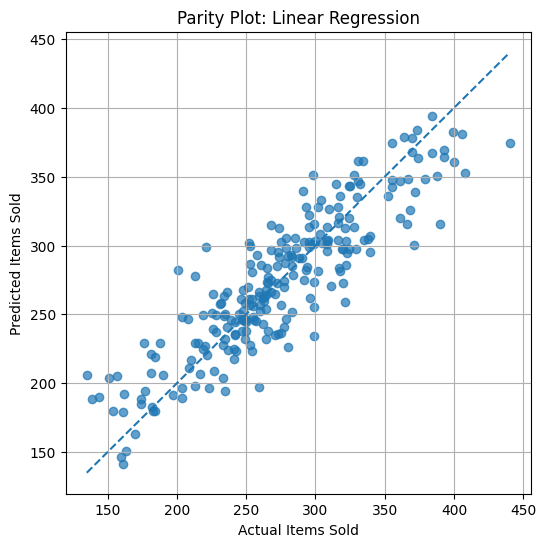

In [17]:
plt.figure(figsize=(6, 6))

plt.scatter(y_test, linear_results["Predictions"], alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle="--")

plt.title("Parity Plot: Linear Regression")
plt.xlabel("Actual Items Sold")
plt.ylabel("Predicted Items Sold")
plt.grid(True)
plt.show()

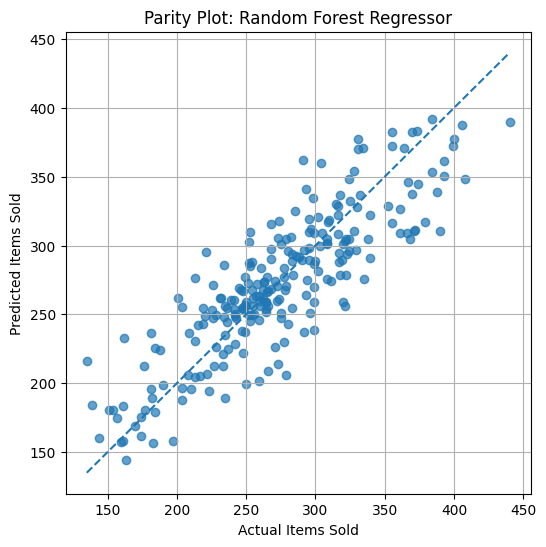

In [19]:
plt.figure(figsize=(6, 6))

plt.scatter(y_test, rf_results["Predictions"], alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle="--")

plt.title("Parity Plot: Random Forest Regressor")
plt.xlabel("Actual Items Sold")
plt.ylabel("Predicted Items Sold")
plt.grid(True)
plt.show()

## Parity Plot Interpretation

The parity plots compare actual `items_sold` values with predicted values.

Points closer to the diagonal reference line indicate better predictions. Points far away from the diagonal line represent larger prediction errors.

These plots help visually compare how well Linear Regression and Random Forest Regressor predict retail sales.

In [20]:
feature_names = random_forest_model.named_steps["preprocessor"].get_feature_names_out()

feature_names

array(['cat__promotion_type_bogo', 'cat__promotion_type_category_offer',
       'cat__promotion_type_flat_discount',
       'cat__promotion_type_free_gift',
       'cat__promotion_type_loyalty_points', 'cat__location_type_rural',
       'cat__location_type_semi-urban', 'cat__location_type_urban',
       'cat__store_size_large', 'cat__store_size_medium',
       'cat__store_size_small', 'num__store_id', 'num__is_weekend',
       'num__is_festival', 'num__competition_density', 'num__year',
       'num__month', 'num__day_of_week', 'num__is_month_end'],
      dtype=object)

In [21]:
rf_importances = random_forest_model.named_steps["model"].feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_importances
}).sort_values(by="Importance", ascending=False)

feature_importance_df.head(10)

,Feature,Importance
13,num__is_festival,0.173396
10,cat__store_size_small,0.167072
7,cat__location_type_urban,0.108311
17,num__day_of_week,0.084269
12,num__is_weekend,0.063097
11,num__store_id,0.054671
5,cat__location_type_rural,0.053755
8,cat__store_size_large,0.051034
14,num__competition_density,0.050716
16,num__month,0.037632


In [22]:
top_5_features = feature_importance_df.head(5)

top_5_features

,Feature,Importance
13,num__is_festival,0.173396
10,cat__store_size_small,0.167072
7,cat__location_type_urban,0.108311
17,num__day_of_week,0.084269
12,num__is_weekend,0.063097


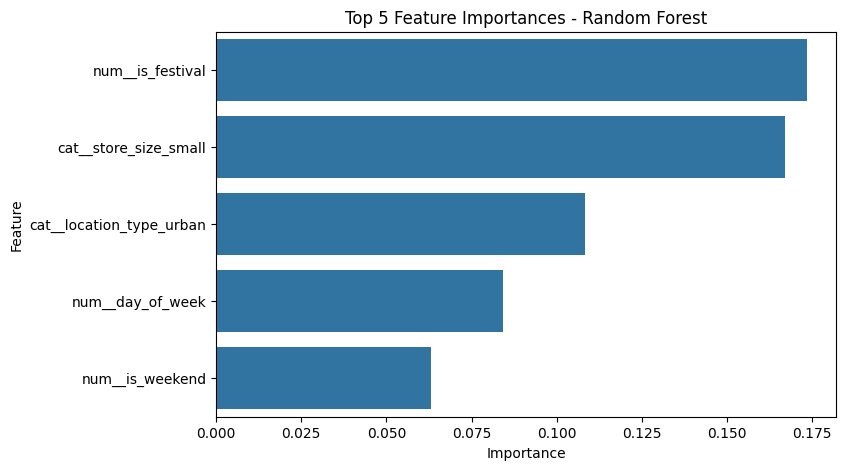

In [23]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=top_5_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 5 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## Feature Importance Interpretation

The Random Forest model was used to identify the most influential features for predicting `items_sold`.

The top 5 most important features are:

1. `num__is_festival`
2. `cat__store_size_small`
3. `cat__location_type_urban`
4. `num__day_of_week`
5. `num__is_weekend`

The most important feature is `is_festival`, which suggests that festival periods have a strong impact on the number of items sold. This makes business sense because customer demand often increases during festivals.

`store_size_small` is also highly important, showing that store size affects sales predictions. `location_type_urban` indicates that store location also plays a key role, possibly because urban stores may have different customer traffic and demand patterns.

The importance of `day_of_week` and `is_weekend` shows that sales are also influenced by weekly timing. This suggests that customer purchase behaviour changes depending on the day and whether the transaction happens on a weekend.

Overall, the Random Forest feature importance results show that sales are mainly influenced by festivals, store characteristics, location type, and weekly timing patterns.